# Matplotlib Example 1: CO2

We're using the [Mauna Loa monthly CO2 averages](https://gml.noaa.gov/ccgg/trends/data.html) to plot the yearly CO2 levels from the 1950s.

In [3]:
import pandas as pd
df = pd.read_csv('co2_mm_mlo.csv')
df

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
809,2025,8,2025.6250,425.48,427.38,24,0.38,0.15
810,2025,9,2025.7083,424.37,427.78,19,0.48,0.21
811,2025,10,2025.7917,424.87,428.11,19,0.32,0.14
812,2025,11,2025.8750,426.46,428.45,20,0.69,0.30


The data is in *long format*. Let's convert it into *wide format* using `df.pivot`.

In [18]:
df_monthly = df.pivot(columns='month',index='year',values='average')
df_monthly

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1958,NaN,NaN,315.71,317.45,317.51,317.27,315.87,314.93,313.21,312.42,313.33,314.67
1959,315.58,316.49,316.65,317.72,318.29,318.15,316.54,314.80,313.84,313.33,314.81,315.58
1960,316.43,316.98,317.58,319.03,320.03,319.58,318.18,315.90,314.17,313.83,315.00,316.19
1961,316.89,317.70,318.54,319.48,320.58,319.77,318.56,316.79,314.99,315.31,316.10,317.01
1962,317.94,318.55,319.68,320.57,321.02,320.62,319.61,317.40,316.24,315.42,316.69,317.70
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,415.49,416.72,417.61,419.01,419.09,418.93,416.90,414.42,413.26,413.90,414.97,416.67
2022,418.13,419.24,418.76,420.19,420.97,420.94,418.85,417.15,415.91,415.74,417.47,419.00
2023,419.47,420.31,420.99,423.31,424.00,423.68,421.83,419.68,418.50,418.82,420.46,421.86


Let's plot the CO2 levels monthly.

In [11]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'CO$_2$ at Mauna Loa (Hawaii)')

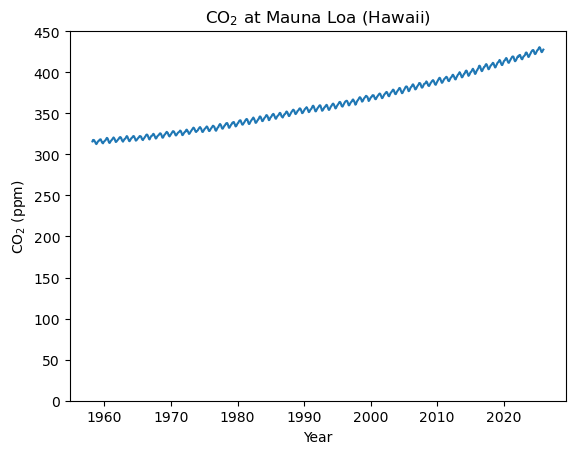

In [16]:
xs = df['decimal date']
ys = df['average']
plt.plot(xs,ys)
plt.ylim(0,450)
plt.xlabel('Year')
plt.ylabel('CO$_2$ (ppm)')
plt.title('CO$_2$ at Mauna Loa (Hawaii)')

Let's *unpivot* the monthly data and compute yearly averages.

In [41]:
df_monthly_long = df_monthly.reset_index().melt(id_vars='year',value_vars=[i for i in range(1,13)],var_name='month',value_name='average')
df_monthly_long

,year,month,average
0,1958,1,NaN
1,1959,1,315.58
2,1960,1,316.43
3,1961,1,316.89
4,1962,1,317.94
...,...,...,...
811,2021,12,416.67
812,2022,12,419.00
813,2023,12,421.86
814,2024,12,425.40


Then group by year and average.

In [42]:
df_annual = df_monthly_long.groupby('year')['average'].mean().reset_index()
df_annual

,year,average
0,1958,315.237000
1,1959,315.981667
2,1960,316.908333
3,1961,317.643333
4,1962,318.453333
...,...,...
63,2021,416.414167
64,2022,418.529167
65,2023,421.075833
66,2024,424.604167


Plot the smoothed data

Text(0.5, 1.0, 'CO$_2$ at Mauna Loa (Hawaii)')

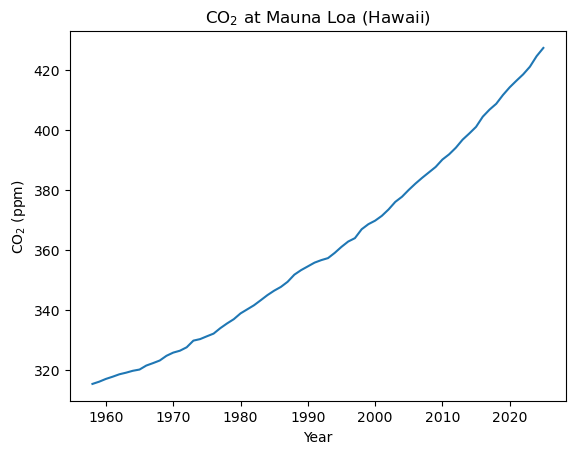

In [45]:
plt.plot(df_annual['year'],df_annual['average'])
plt.xlabel('Year')
plt.ylabel('CO$_2$ (ppm)')
plt.title('CO$_2$ at Mauna Loa (Hawaii)')